In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)


Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Pandas version: 3.0.0


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


In [3]:
from src.baseline.diesel_baseline import diesel_fleet_sizing


In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "synthetic"

trips = pd.read_csv(
    DATA_DIR / "trips.csv",
    parse_dates=["start_time", "end_time"]
)

print(trips.shape)
trips.head()


(114, 9)


,trip_id,cycle_id,direction,start_time,end_time,distance_km,num_stops,is_peak,energy_kwh
0,1,0,0,1900-01-01 06:00:00.000000,1900-01-01 06:28:58.999725,12,24,False,17.414789
1,2,0,1,1900-01-01 06:34:58.999725,1900-01-01 07:03:57.999450,12,24,False,18.106499
2,3,1,0,1900-01-01 06:18:00.000000,1900-01-01 06:46:01.610790,12,24,False,18.220177
3,4,1,1,1900-01-01 06:52:01.610790,1900-01-01 07:20:03.221580,12,24,False,17.567103
4,5,2,0,1900-01-01 06:40:00.000000,1900-01-01 07:07:53.942518,12,24,False,18.549032


In [5]:
results = diesel_fleet_sizing(trips)

results


{'N_diesel_theoretical': 8,
 'N_diesel_block': 11,
 'cycle_time_min': np.float64(70.05696555204678),
 'avg_headway_min': np.float64(9.371371603030303),
 'peak_hour': np.int32(9)}

In [6]:
cycle = results['cycle_time_min']
headway = results['avg_headway_min']
fleet = results['N_diesel_theoretical']

print("Cycle / Headway:", cycle/headway)
print("Fleet:", fleet)


Cycle / Headway: 7.475636280327773
Fleet: 8


In [7]:
blocks = pd.read_csv(
    PROJECT_ROOT / "results" / "synthetic" / "diesel_blocks.csv"
)

blocks.head()


,trip_id,bus_id
0,1,0
1,3,1
2,2,0
3,5,2
4,4,1


In [8]:
util = blocks.bus_id.value_counts()

util.describe()


count    11.000000
mean     10.363636
std      10.151578
min       1.000000
25%       3.000000
50%       5.000000
75%      21.500000
max      25.000000
Name: count, dtype: float64

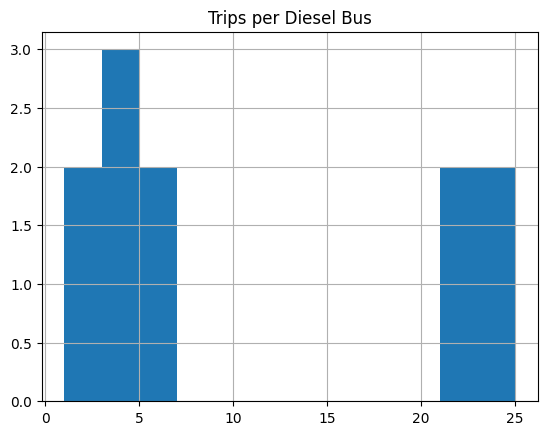

In [9]:
util.hist(bins=12)
plt.title("Trips per Diesel Bus")
plt.show()


In [10]:
merged = blocks.merge(trips, on="trip_id")

bus0 = merged[merged.bus_id == 0]

bus0[['start_time','end_time']].sort_values('start_time')


,start_time,end_time
0,1900-01-01 06:00:00.000000,1900-01-01 06:28:58.999725
2,1900-01-01 06:34:58.999725,1900-01-01 07:03:57.999450
6,1900-01-01 07:13:53.942518,1900-01-01 07:41:47.885036
11,1900-01-01 07:52:00.000000,1900-01-01 08:32:35.041402
19,1900-01-01 08:38:35.041402,1900-01-01 09:19:10.082804
29,1900-01-01 09:27:50.801781,1900-01-01 10:08:41.603562
40,1900-01-01 10:24:52.391052,1900-01-01 11:05:44.782104
48,1900-01-01 11:22:31.290692,1900-01-01 11:51:02.581384
52,1900-01-01 12:05:45.415765,1900-01-01 12:35:30.831530
56,1900-01-01 12:42:40.699294,1900-01-01 13:11:21.398588


In [11]:
summary = pd.DataFrame([results])

summary.to_csv(
    PROJECT_ROOT / "results" / "synthetic" / "diesel_validation_summary.csv",
    index=False
)
